## Transfer Learning

Create API key in Kaggle and copy the kaggle.json into /content directory

## Download the data from kaggle as zip file

In [1]:
!mkdir -p ~/.kaggle # Creates a directory named .kaggle in the user's home directory if it doesn't exist
!cp kaggle.json ~/.kaggle/ # Copies the kaggle.json file to the .kaggle directory
!kaggle datasets download -d salader/dogs-vs-cats # Downloads the dogs-vs-cats dataset using the Kaggle API

Dataset URL: https://www.kaggle.com/datasets/salader/dogs-vs-cats
License(s): unknown


## Uncompress the zip file

In [2]:
import zipfile # Imports the zipfile module for working with zip files
zip_ref = zipfile.ZipFile('/content/dogs-vs-cats.zip', 'r') # Creates a ZipFile object for the dogs-vs-cats.zip file
zip_ref.extractall('/content') # Extracts all files from the zip file to the /content directory
zip_ref.close() # Closes the ZipFile object

## Import libraries

In [3]:
import tensorflow # Imports the TensorFlow library
from tensorflow import keras # Imports the Keras module from TensorFlow
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt # Imports the matplotlib.pyplot module for plotting
from keras import Sequential # Imports the Sequential model from Keras
from keras.layers import Dense,Flatten # Imports the Dense and Flatten layers from Keras
from keras.applications.vgg16 import VGG16 # Imports the VGG16 model from Keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Imports the ImageDataGenerator class for data augmentation

## Create a VGG16 model instance

### What is VGG16?

VGG16 is a convolutional neural network (CNN) architecture. It's a 16-layer network (hence the "16") known for its simplicity and effectiveness in image classification tasks. It became quite famous after achieving top results in the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) in 2014.

### What is ImageNet?

ImageNet is a massive dataset of labeled images. It contains millions of images categorized into thousands of object classes. It's widely used for training and evaluating computer vision models.

The weights='imagenet' argument means you're loading the VGG16 model with weights that have been pre-trained on the ImageNet dataset. This is a powerful technique called transfer learning, as it allows you to leverage the knowledge learned from a massive dataset to kickstart your own model training.

### Why exclude the top?

The "top" of the VGG16 model refers to the final fully connected layers that are responsible for classification into the 1000 ImageNet categories.

By setting `include_top = False`, you're removing those final layers. You typically do this because:

- Custom Classification: It is used to train your model to classify into a different set of categories than the original ImageNet ones.
- Feature Extraction: You might want to use VGG16 as a feature extractor. The convolutional layers learn rich representations of images, and you can use those features as input to your own custom classifier.

In [4]:
conv_base = VGG16( # Creates a VGG16 model instance
    weights='imagenet', # Loads pre-trained weights from ImageNet
    include_top = False, # Excludes the fully connected layers at the top of the model
    input_shape=(150,150,3) # Specifies the input shape for the model
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Building a Sequential Model

- `model = Sequential()`: This line creates an instance of the Sequential model in Keras. The Sequential model is a linear stack of layers, meaning layers are added one after another in a sequential manner. It is the simplest type of model in Keras and it is well-suited for many problems.

### Adding the Convolutional Base (VGG16)

- `model.add(conv_base)`: Here, you're adding the pre-trained VGG16 convolutional base (conv_base, which you defined earlier) to your model. This convolutional base acts as a powerful feature extractor, having learned to recognize various patterns and features in images during its training on ImageNet.

### Flattening the Output

- `model.add(Flatten())`: The output of the convolutional base is a multi-dimensional tensor (think of it as a grid of features). To feed this output into a fully connected layer (which expects a 1D vector), you need to flatten it. The Flatten layer does exactly this – it transforms the multi-dimensional output into a single, long 1D vector.

### Adding Fully Connected Layers (Dense Layers)

- `model.add(Dense(256, activation='relu'))`: This line adds a densely connected layer (also called a fully connected layer) with 256 units (neurons) to your model.

 - Dense: In a dense layer, each neuron is connected to every neuron in the previous layer.
 - 256 units: This determines the dimensionality of the output of this layer.
 - ReLU activation: The Rectified Linear Unit (ReLU) is a popular activation function that introduces non-linearity into the - model, making it capable of learning complex patterns. It's defined as f(x) = max(0, x).
- `model.add(Dense(1, activation='sigmoid'))`: This line adds another dense layer, but this one has only 1 unit and uses the sigmoid activation function.

 - 1 unit: Since this is a binary classification problem (cats vs. dogs), you only need one output unit to represent the probability of an image belonging to a particular class.
 - Sigmoid activation: The sigmoid function squashes the output between 0 and 1, making it suitable for representing probabilities. A value closer to 1 indicates a higher probability of the image being a dog, and a value closer to 0 suggests it's more likely to be a cat.


In [5]:
model = Sequential() # Creates a Sequential model

model.add(conv_base) # Adds the VGG16 convolutional base to the model
model.add(Flatten()) # Adds a Flatten layer to convert the output of the convolutional base to a 1D vector
model.add(Dense(256,activation='relu')) # Adds a Dense layer with 256 units and ReLU activation
model.add(Dense(1,activation='sigmoid')) # Adds a Dense layer with 1 unit and sigmoid activation for binary classification

## Freezes the weights of the convolutional base
### Why? is it necessary?

- Keeps valuable pre-trained features intact.
- Speeds up training.
- Prevents overfitting (especially with smaller datasets).

Essentially, it lets you use VGG16 as a powerful, fixed feature extractor, while training only your new custom layers for your specific task.

In [6]:
conv_base.trainable = False # Freezes the weights of the convolutional base

## Data Preparation and Augmentation

- `ImageDataGenerator`: This is a powerful tool in Keras for preparing image data for training deep learning models. It allows you to perform data augmentation, which helps prevent overfitting and improves model generalization.

- `train_datagen`: This creates an ImageDataGenerator specifically for your training data. It includes the following augmentations:

 - `rescale=1./255`: This normalizes pixel values to a range of 0 to 1, which is a common practice for image preprocessing.
 - `shear_range=0.2`: Applies random shearing transformations (slightly tilting the image).
 - `zoom_range=0.2`: Randomly zooms in or out on the image.
 - `horizontal_flip=True`: Flips the image horizontally with a 50% probability.
- `test_datagen:` This creates an `ImageDataGenerator` for your test (or validation) data. Notice that it only includes rescale, as you typically don't augment your test data.

- `train_generator` and `validation_generator`: These use the `flow_from_directory` method to create generators that load your training and validation images in batches.

 - `'/content/train'` and `'/content/test'`: These are the directory paths where your training and validation images are located.
 - `target_size=(150, 150)`: All images will be resized to 150x150 pixels.
 - `batch_size=batch_size`: Sets the batch size (how many images are loaded at a time).
 - `class_mode='binary'`: This indicates that it's a binary classification problem (e.g., cat vs. dog).

### Why This Is Important

- Efficiency: Generators load data on the fly, which saves memory, especially when dealing with large image datasets.
- Data Augmentation: By augmenting your training data, you effectively create more variations of your images, which helps the model generalize better to new, unseen data.
- Batch Processing: Training with batches of data is typically more efficient than training one image at a time.

In essence, this code snippet creates a system for loading, preprocessing, and augmenting your image data in a way that is optimized for training a deep learning model. I hope this explanation is helpful! Let me know if you have any other questions.

In [7]:
batch_size = 32 # Sets the batch size for training

train_datagen = ImageDataGenerator( # Creates an ImageDataGenerator for training data
        rescale=1./255, # Rescales pixel values to the range [0, 1]
        shear_range=0.2, # Applies random shear transformations
        zoom_range=0.2, # Applies random zoom transformations
        horizontal_flip=True) # Applies random horizontal flips

test_datagen = ImageDataGenerator(rescale=1./255) # Creates an ImageDataGenerator for test data with only rescaling

train_generator = train_datagen.flow_from_directory( # Creates a data generator for training data
        '/content/train', # Specifies the directory containing training images
        target_size=(150, 150), # Resizes images to the target size
        batch_size=batch_size, # Sets the batch size
        class_mode='binary') # Specifies binary classification mode

validation_generator = test_datagen.flow_from_directory( # Creates a data generator for validation data
        '/content/test', # Specifies the directory containing validation images
        target_size=(150, 150), # Resizes images to the target size
        batch_size=batch_size, # Sets the batch size
        class_mode='binary') # Specifies binary classification mode

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


## Compile the model
### model.compile configures your model for training:

- `optimizer='adam'`: Chooses the Adam algorithm to efficiently update the model's weights during training.
- `loss='binary_crossentropy'`: Uses binary cross-entropy to measure the error for binary classification problems.
- `metrics=['accuracy']`: Tracks accuracy to evaluate the model's performance.

In short, it sets up the learning process, error measurement, and performance evaluation for your model.

In [8]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy']) # Compiles the model with Adam optimizer, binary cross-entropy loss, and accuracy metric

## Train the model
`model.fit` trains the model:

- `train_generator`: Feeds training data to the model in batches.
- `epochs=10`: Specifies the number of times the model sees the entire training dataset.
- `validation_data=validation_generator`: Evaluates the model on separate data during training to prevent overfitting.

In essence, `model.fit` starts the learning process, using training data to improve the model's performance over multiple epochs and validation data to monitor its progress. The history object stores the training results for analysis.

In [9]:
history = model.fit( # Trains the model
    train_generator, # Uses the training data generator
    epochs=10, # Sets the number of training epochs
    validation_data=validation_generator # Uses the validation data generator
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 167s 254ms/step - accuracy: 0.8265 - loss: 0.4352 - val_accuracy: 0.8680 - val_loss: 0.3154
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 157s 251ms/step - accuracy: 0.8908 - loss: 0.2509 - val_accuracy: 0.9104 - val_loss: 0.2090
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 251ms/step - accuracy: 0.9063 - loss: 0.2197 - val_accuracy: 0.9150 - val_loss: 0.1979
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 198s 244ms/step - accuracy: 0.9137 - loss: 0.2048 - val_accuracy: 0.9178 - val_loss: 0.1975
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 157s 252ms/step - accuracy: 0.9149 - loss: 0.1978 - val_accuracy: 0.9232 - val_loss: 0.1843
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 155s 248ms/step - accuracy: 0.9222 - loss: 0.1861 - val_accuracy: 0.9088 - val_loss: 0.2169
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 201s 246ms/step - accuracy: 0.9242 - loss: 0.1781 - val_accuracy: 0.9226 - val_loss: 0.1804
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 154s 247ms/step - accuracy: 0.9303 -

## Plot the Training and Validation accuracy curve

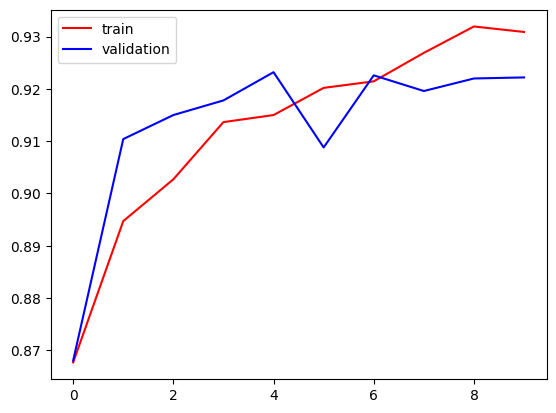

In [10]:
plt.plot(history.history['accuracy'],color='red',label='train') # Plots the training accuracy
plt.plot(history.history['val_accuracy'],color='blue',label='validation') # Plots the validation accuracy
plt.legend() # Displays the legend
plt.show() # Shows the plot

## Plot the Training and Validation loss curve

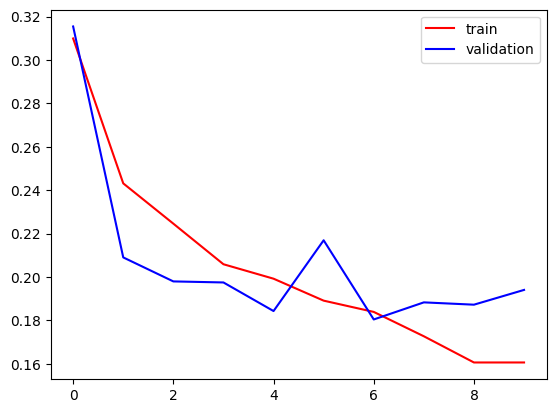

In [11]:
plt.plot(history.history['loss'],color='red',label='train') # Plots the training loss
plt.plot(history.history['val_loss'],color='blue',label='validation') # Plots the validation loss
plt.legend() # Displays the legend
plt.show() # Shows the plot

## Funtion to predict the class of the image
The `predict_image_class` function takes an image path and a trained model, then:

- Preprocesses the image: Loads, resizes, converts to an array, and rescales pixel values.
- Predicts the class: Uses the model to get a probability score, then classifies based on a threshold.
- Displays the result: Shows the image with the predicted class label (Cat or Dog).

In short, it takes an image, uses the model to predict its class, and shows you the result.



In [12]:
def predict_image_class(image_path, model):
  img = image.load_img(image_path, target_size=(150, 150))  # Load and resize image
  img_array = image.img_to_array(img)  # Convert to NumPy array
  img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
  img_array = img_array / 255.0  # Rescale pixel values

  prediction = model.predict(img_array)  # Make prediction
  predicted_class = int(prediction[0][0] > 0.5)  # Get class based on threshold

  # Display the image
  plt.imshow(img)
  plt.axis('off')  # Turn off axis labels

  # Print the predicted class
  if predicted_class == 0:
    plt.title("Predicted class: Cat")
  else:
    plt.title("Predicted class: Dog")

  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


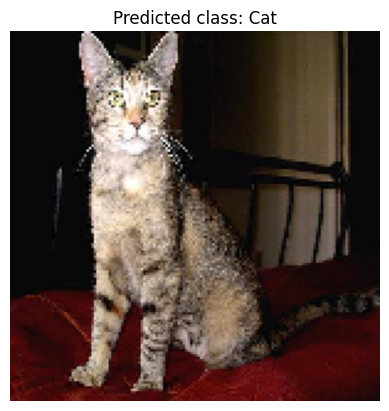

In [13]:
# Example usage:
image_path = '/content/test/cats/cat.10000.jpg'  # Replace with your image path
predict_image_class(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


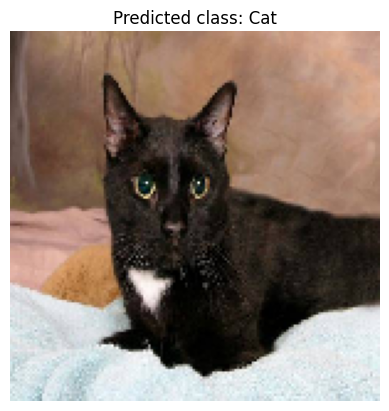

In [14]:
predict_image_class('/content/test/cats/cat.10128.jpg', model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


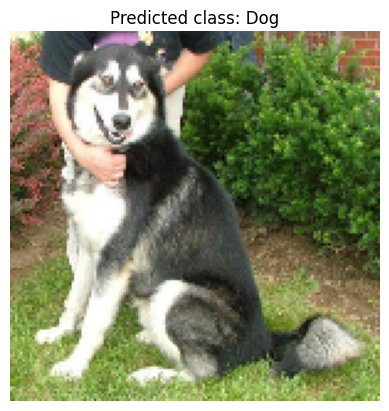

In [15]:
predict_image_class('/content/test/dogs/dog.10021.jpg', model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


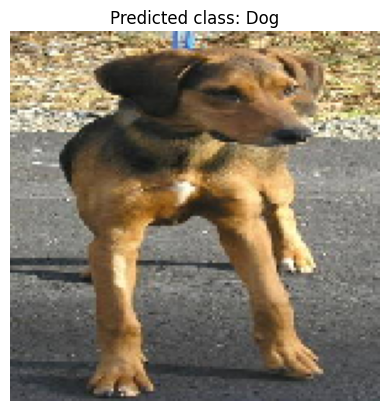

In [16]:
predict_image_class('/content/test/dogs/dog.10249.jpg', model)